# Rürup Rente Tariff Comparison

Comparing three tariffs: **Alte Leipziger (HFR70)**, **Condor (C79 H)**, and **LV1871 (MeinPlan)**

**Investment Strategy:**
- Monthly contribution: 30€
- Yearly Zuzahlung: 10,000€
- Age: 31 → 67 (36 years accumulation)
- ETF TER: 0.2% (additional cost for all tariffs)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


## Define Tariff Parameters

In [2]:
# Tariff parameters
tariffs = {
    'Alte Leipziger HFR70': {
        'alpha': 0.0,           # Abschlusskosten (% of sum)
        'beta': 0.0,            # Kosten vom Beitrag p.a. (%)
        'gamma': 0.30,          # Kosten vom Guthaben p.a. (%)
        'kappa': 36.0,          # Fixe Kosten EUR p.a.
        'zuzahlung_cost': 0.0,  # Kosten bei Zuzahlungen (%)
        'etf_ter': 0.20,        # ETF TER (%)
        'pension_cost': 1.50,   # Kosten in Rentenphase (%)
        # Features
        'guaranteed_rentenfaktor_zuzahlung': False,
        'treuhänder_verzicht': True,
        'teilverrentung': False,
        'fondsgebundener_rentenbezug': False,
    },
    'Condor C79 H': {
        'alpha': 0.0,
        'beta': 4.50,           # 4.5% on contributions
        'gamma': 0.24,
        'kappa': 0.0,
        'zuzahlung_cost': 0.0,
        'etf_ter': 0.20,
        'pension_cost': 1.50,
        'guaranteed_rentenfaktor_zuzahlung': True,
        'treuhänder_verzicht': True,
        'teilverrentung': True,
        'fondsgebundener_rentenbezug': False,
    },
    'LV1871 MeinPlan': {
        'alpha': 0.0,
        'beta': 2.20,           # 2.2% on contributions
        'gamma': 0.22,
        'kappa': 30.0,
        'zuzahlung_cost': 0.50, # 0.5% on Zuzahlung
        'etf_ter': 0.20,
        'pension_cost': 1.50,
        'guaranteed_rentenfaktor_zuzahlung': True,
        'treuhänder_verzicht': True,
        'teilverrentung': False,
        'fondsgebundener_rentenbezug': True,
    }
}

# Display parameters as DataFrame
params_display = pd.DataFrame({
    name: {
        'Beta (Beitragskosten %)': t['beta'],
        'Gamma (Guthabenkosten %)': t['gamma'],
        'Kappa (Fixkosten €)': t['kappa'],
        'Zuzahlung Kosten %': t['zuzahlung_cost'],
        'ETF TER %': t['etf_ter'],
        'Total Asset Cost %': t['gamma'] + t['etf_ter'],
    }
    for name, t in tariffs.items()
}).T

print("Tariff Cost Parameters:")
params_display

Tariff Cost Parameters:


,Beta (Beitragskosten %),Gamma (Guthabenkosten %),Kappa (Fixkosten €),Zuzahlung Kosten %,ETF TER %,Total Asset Cost %
Alte Leipziger HFR70,0.00,0.30,36.00,0.00,0.20,0.50
Condor C79 H,4.50,0.24,0.00,0.00,0.20,0.44
LV1871 MeinPlan,2.20,0.22,30.00,0.50,0.20,0.42


## Contribution Schedule

- **Monthly contributions:** 30€ × 12 = 360€/year
- **Yearly Zuzahlung:** 10,000€/year  
- **Total annual contribution:** 10,360€
- **Investment period:** 36 years (age 31 → 67)

In [3]:
# Investment parameters
monthly_contribution = 30.0      # EUR per month
yearly_zuzahlung = 10000.0       # EUR per year
years = 36                        # Age 31 to 67
assumed_gross_return = 6.0       # % annual return before costs

# Calculate total contributions
yearly_regular = monthly_contribution * 12  # 360 EUR
yearly_total = yearly_regular + yearly_zuzahlung  # 10,360 EUR
total_contributions = yearly_total * years

print(f"Investment Period: {years} years")
print(f"Monthly Contribution: {monthly_contribution:,.0f}€")
print(f"Yearly Zuzahlung: {yearly_zuzahlung:,.0f}€")
print(f"Total Annual Contribution: {yearly_total:,.0f}€")
print(f"Total Contributions over {years} years: {total_contributions:,.0f}€")
print(f"Assumed Gross Return: {assumed_gross_return}% p.a.")

Investment Period: 36 years
Monthly Contribution: 30€
Yearly Zuzahlung: 10,000€
Total Annual Contribution: 10,360€
Total Contributions over 36 years: 372,960€
Assumed Gross Return: 6.0% p.a.


## Simulate Portfolio Growth with Costs

For each tariff, we simulate year-by-year:
1. **Beta costs** deducted from monthly contributions (not from Zuzahlung since Zuzahlung cost is separate)
2. **Zuzahlung costs** deducted from yearly Zuzahlung
3. **Gamma + ETF TER** deducted from accumulated assets
4. **Kappa** fixed costs deducted annually

In [4]:
def simulate_portfolio(tariff_params, years, monthly_contrib, yearly_zuzahlung, gross_return_pct):
    """
    Simulate portfolio growth with all costs applied.
    
    Returns:
        portfolio_values: list of end-of-year portfolio values
        total_costs: total costs paid over the period
        yearly_costs: list of costs per year
    """
    beta = tariff_params['beta'] / 100
    gamma = tariff_params['gamma'] / 100
    kappa = tariff_params['kappa']
    zuzahlung_cost = tariff_params['zuzahlung_cost'] / 100
    etf_ter = tariff_params['etf_ter'] / 100
    gross_return = gross_return_pct / 100
    
    portfolio = 0.0
    portfolio_values = []
    yearly_costs_list = []
    total_costs = 0.0
    
    for year in range(1, years + 1):
        yearly_costs = 0.0
        
        # Monthly contributions with beta costs
        yearly_regular = monthly_contrib * 12
        beta_cost_on_regular = yearly_regular * beta
        net_regular = yearly_regular - beta_cost_on_regular
        yearly_costs += beta_cost_on_regular
        
        # Zuzahlung with Zuzahlung costs
        zuzahlung_fee = yearly_zuzahlung * zuzahlung_cost
        net_zuzahlung = yearly_zuzahlung - zuzahlung_fee
        yearly_costs += zuzahlung_fee
        
        # Add contributions to portfolio (simplified: added at start of year)
        portfolio += net_regular + net_zuzahlung
        
        # Apply investment return
        investment_gain = portfolio * gross_return
        portfolio += investment_gain
        
        # Deduct gamma (insurer asset cost) and ETF TER
        asset_cost_rate = gamma + etf_ter
        asset_cost = portfolio * asset_cost_rate
        portfolio -= asset_cost
        yearly_costs += asset_cost
        
        # Deduct kappa (fixed annual costs)
        portfolio -= kappa
        yearly_costs += kappa
        
        portfolio_values.append(portfolio)
        yearly_costs_list.append(yearly_costs)
        total_costs += yearly_costs
    
    return portfolio_values, total_costs, yearly_costs_list


def simulate_no_cost_portfolio(years, monthly_contrib, yearly_zuzahlung, gross_return_pct):
    """Simulate portfolio with zero costs (benchmark)."""
    gross_return = gross_return_pct / 100
    portfolio = 0.0
    portfolio_values = []
    yearly_contrib = monthly_contrib * 12 + yearly_zuzahlung
    
    for year in range(1, years + 1):
        portfolio += yearly_contrib
        portfolio *= (1 + gross_return)
        portfolio_values.append(portfolio)
    
    return portfolio_values

# Run simulations
results = {}
for name, params in tariffs.items():
    portfolio_values, total_costs, yearly_costs = simulate_portfolio(
        params, years, monthly_contribution, yearly_zuzahlung, assumed_gross_return
    )
    results[name] = {
        'portfolio_values': portfolio_values,
        'final_value': portfolio_values[-1],
        'total_costs': total_costs,
        'yearly_costs': yearly_costs,
    }

# Benchmark (no costs)
no_cost_values = simulate_no_cost_portfolio(years, monthly_contribution, yearly_zuzahlung, assumed_gross_return)
results['No Costs (Benchmark)'] = {
    'portfolio_values': no_cost_values,
    'final_value': no_cost_values[-1],
    'total_costs': 0,
    'yearly_costs': [0] * years,
}

print("Simulation complete!")

Simulation complete!


## Calculate Effective Cost Ratio (Effektivkosten)

The effective cost ratio shows the annual return reduction due to costs. It's calculated by finding the rate that explains the difference between gross and net portfolio values.

In [5]:
def calculate_effective_cost(final_with_costs, final_no_costs, gross_return, years):
    """
    Calculate effective annual cost rate.
    
    The effective cost is the annual rate that reduces gross return to achieve
    the same final value as the cost-laden portfolio.
    """
    if final_no_costs == 0:
        return 0
    
    # Ratio of actual to ideal portfolio
    ratio = final_with_costs / final_no_costs
    
    # Implied annual reduction factor
    # If no costs: FV = contributions compounded at gross_return
    # With costs: FV = contributions compounded at (gross_return - effective_cost)
    # ratio = (1 + net_return)^years / (1 + gross_return)^years (approximately for complex case)
    
    # Simpler approach: calculate the return that would give us the cost-laden final value
    # This is an approximation since contributions are spread over time
    
    # Using geometric mean approach
    effective_net_return = (final_with_costs / final_no_costs) ** (1 / years) * (1 + gross_return / 100) - 1
    effective_cost_rate = gross_return / 100 - effective_net_return
    
    return effective_cost_rate * 100  # Return as percentage

# Calculate effective costs
no_cost_final = results['No Costs (Benchmark)']['final_value']

for name in tariffs.keys():
    final_value = results[name]['final_value']
    eff_cost = calculate_effective_cost(final_value, no_cost_final, assumed_gross_return, years)
    results[name]['effective_cost_pct'] = eff_cost
    
    # Also calculate cost as percentage of final no-cost value
    cost_drag_pct = (no_cost_final - final_value) / no_cost_final * 100
    results[name]['cost_drag_pct'] = cost_drag_pct

print("Effective cost calculation complete!")

Effective cost calculation complete!


## Summary: Side-by-Side Comparison

In [7]:
# Create summary table
summary_data = []

for name in tariffs.keys():
    t = tariffs[name]
    r = results[name]
    
    summary_data.append({
        'Tariff': name,
        'Final Portfolio (€)': r['final_value'],
        'Total Costs Paid (€)': r['total_costs'],
        'Cost Drag vs No-Cost (€)': no_cost_final - r['final_value'],
        'Effective Cost (% p.a.)': r['effective_cost_pct'],
        'Beta (%)': t['beta'],
        'Gamma + TER (%)': t['gamma'] + t['etf_ter'],
        'Kappa (€)': t['kappa'],
        'Zuzahlung Cost (%)': t['zuzahlung_cost'],
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.set_index('Tariff')

# Add benchmark
summary_df.loc['No Costs (Benchmark)'] = [
    no_cost_final, 0, 0, 0, 0, 0, 0, 0
]

print("=" * 80)
print("RÜRUP RENTE TARIFF COMPARISON - COST ANALYSIS")
print("=" * 80)
print(f"\nInvestment: 30€/month + 10,000€/year Zuzahlung for {years} years")
print(f"Assumed gross return: {assumed_gross_return}% p.a.")
print(f"Total contributions: {total_contributions:,.0f}€")
print("\n")

# Display without styling
pd.options.display.float_format = '{:,.2f}'.format
display(summary_df)

RÜRUP RENTE TARIFF COMPARISON - COST ANALYSIS

Investment: 30€/month + 10,000€/year Zuzahlung for 36 years
Assumed gross return: 6.0% p.a.
Total contributions: 372,960€




,Final Portfolio (€),Total Costs Paid (€),Cost Drag vs No-Cost (€),Effective Cost (% p.a.),Beta (%),Gamma + TER (%),Kappa (€),Zuzahlung Cost (%)
Tariff,,,,,,,,
Alte Leipziger HFR70,"1,155,186.86","77,213.21","152,950.85",0.37,0.00,0.50,36.00,0.00
Condor C79 H,"1,174,021.94","68,149.94","134,115.77",0.32,4.50,0.44,0.00,0.00
LV1871 MeinPlan,"1,171,692.62","67,434.74","136,445.09",0.32,2.20,0.42,30.00,0.50
No Costs (Benchmark),"1,308,137.71",0.00,0.00,0.00,0.00,0.00,0.00,0.00


## Detailed Annual Cost Breakdown

In [9]:
# Calculate detailed cost breakdown for each tariff
def calculate_cost_breakdown(tariff_name, tariff_params, years, monthly_contrib, yearly_zuzahlung, gross_return_pct):
    beta = tariff_params['beta'] / 100
    gamma = tariff_params['gamma'] / 100
    kappa = tariff_params['kappa']
    zuzahlung_cost_rate = tariff_params['zuzahlung_cost'] / 100
    etf_ter = tariff_params['etf_ter'] / 100
    
    total_beta = 0
    total_gamma = 0
    total_kappa = 0
    total_zuzahlung_cost = 0
    total_etf_ter = 0
    
    portfolio = 0.0
    
    for year in range(1, years + 1):
        # Beta on monthly contributions
        yearly_regular = monthly_contrib * 12
        beta_cost = yearly_regular * beta
        total_beta += beta_cost
        
        # Zuzahlung cost
        zuzahlung_fee = yearly_zuzahlung * zuzahlung_cost_rate
        total_zuzahlung_cost += zuzahlung_fee
        
        # Add net contributions
        net_contrib = yearly_regular - beta_cost + yearly_zuzahlung - zuzahlung_fee
        portfolio += net_contrib
        
        # Investment growth
        portfolio *= (1 + gross_return_pct / 100)
        
        # Gamma cost (insurer)
        gamma_cost = portfolio * gamma
        total_gamma += gamma_cost
        
        # ETF TER cost
        ter_cost = portfolio * etf_ter
        total_etf_ter += ter_cost
        
        # Deduct costs
        portfolio -= gamma_cost + ter_cost + kappa
        total_kappa += kappa
    
    return {
        'Beta Costs (Beitragskosten)': total_beta,
        'Gamma Costs (Guthabenkosten)': total_gamma,
        'Kappa Costs (Fixkosten)': total_kappa,
        'Zuzahlung Costs': total_zuzahlung_cost,
        'ETF TER Costs': total_etf_ter,
        'TOTAL COSTS': total_beta + total_gamma + total_kappa + total_zuzahlung_cost + total_etf_ter,
    }

# Calculate for each tariff
breakdown_data = {}
for name, params in tariffs.items():
    breakdown_data[name] = calculate_cost_breakdown(
        name, params, years, monthly_contribution, yearly_zuzahlung, assumed_gross_return
    )

breakdown_df = pd.DataFrame(breakdown_data).T
print("Detailed Cost Breakdown (EUR over 36 years):")
print("=" * 70)
display(breakdown_df)

Detailed Cost Breakdown (EUR over 36 years):


,Beta Costs (Beitragskosten),Gamma Costs (Guthabenkosten),Kappa Costs (Fixkosten),Zuzahlung Costs,ETF TER Costs,TOTAL COSTS
Alte Leipziger HFR70,0.00,"45,550.32","1,296.00",0.00,"30,366.88","77,213.21"
Condor C79 H,583.20,"36,854.58",0.00,0.00,"30,712.15","68,149.94"
LV1871 MeinPlan,285.12,"33,665.04","1,080.00","1,800.00","30,604.58","67,434.74"


## Visualizations

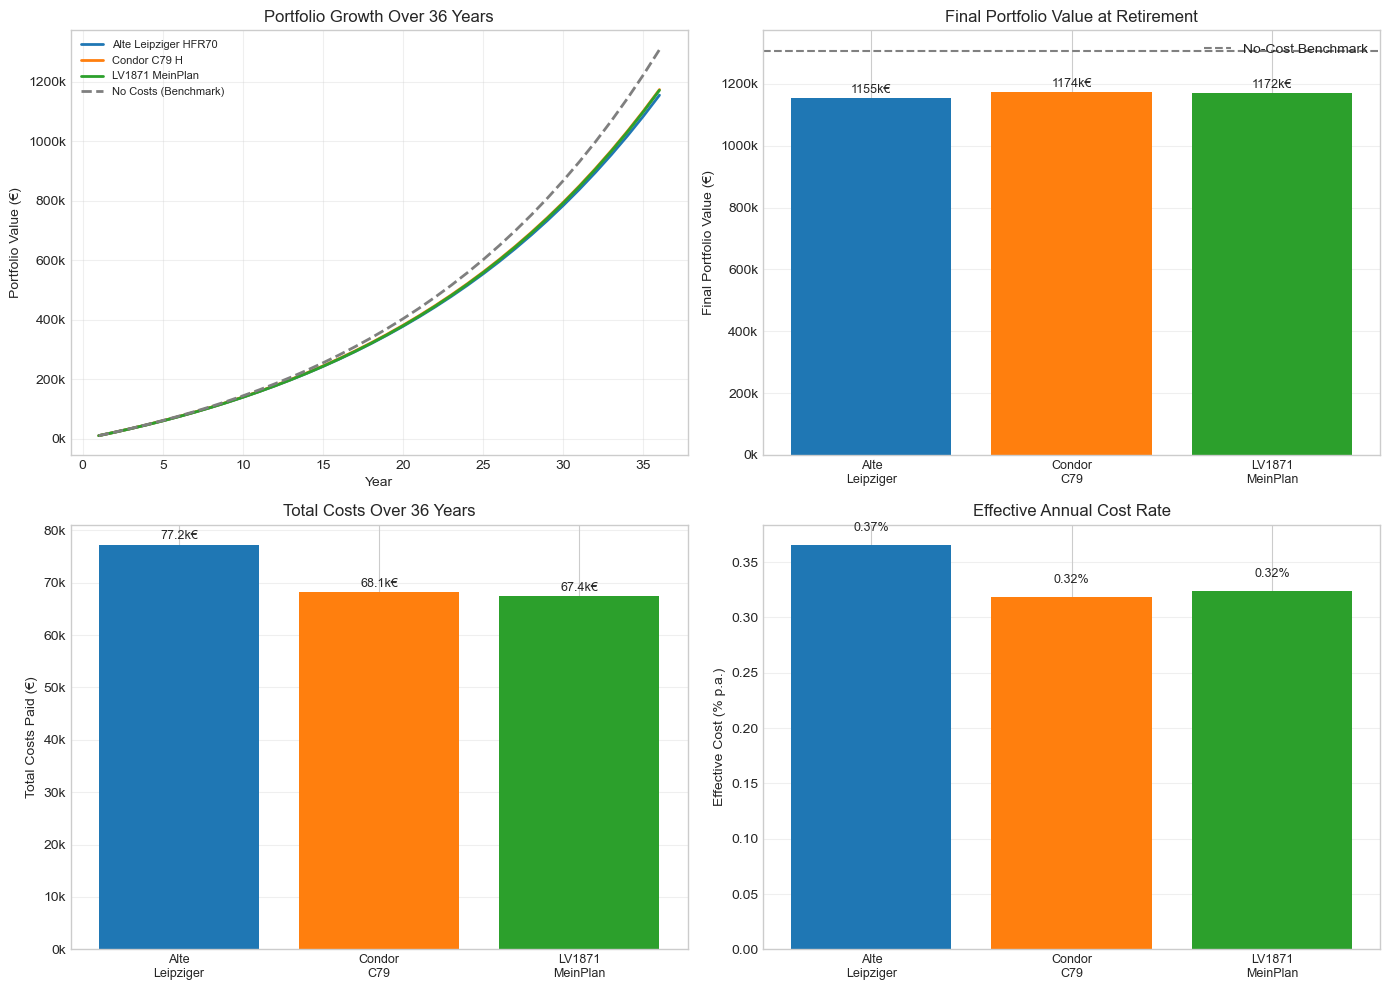


Chart saved as 'ruerup_comparison.png'


In [10]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Colors for tariffs
colors = {'Alte Leipziger HFR70': '#1f77b4', 'Condor C79 H': '#ff7f0e', 
          'LV1871 MeinPlan': '#2ca02c', 'No Costs (Benchmark)': '#7f7f7f'}

# 1. Portfolio Growth Over Time
ax1 = axes[0, 0]
years_range = range(1, years + 1)
for name in list(tariffs.keys()) + ['No Costs (Benchmark)']:
    ax1.plot(years_range, results[name]['portfolio_values'], 
             label=name, color=colors[name], linewidth=2,
             linestyle='--' if name == 'No Costs (Benchmark)' else '-')
ax1.set_xlabel('Year')
ax1.set_ylabel('Portfolio Value (€)')
ax1.set_title('Portfolio Growth Over 36 Years')
ax1.legend(loc='upper left', fontsize=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
ax1.grid(True, alpha=0.3)

# 2. Final Portfolio Values Comparison
ax2 = axes[0, 1]
tariff_names = list(tariffs.keys())
final_values = [results[name]['final_value'] for name in tariff_names]
bar_colors = [colors[name] for name in tariff_names]
bars = ax2.bar(range(len(tariff_names)), final_values, color=bar_colors)
ax2.axhline(y=no_cost_final, color='gray', linestyle='--', label='No-Cost Benchmark')
ax2.set_xticks(range(len(tariff_names)))
ax2.set_xticklabels([name.split()[0] + '\n' + name.split()[1] for name in tariff_names], fontsize=9)
ax2.set_ylabel('Final Portfolio Value (€)')
ax2.set_title('Final Portfolio Value at Retirement')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
for bar, val in zip(bars, final_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
             f'{val/1000:.0f}k€', ha='center', va='bottom', fontsize=9)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Total Costs Comparison
ax3 = axes[1, 0]
total_costs = [results[name]['total_costs'] for name in tariff_names]
bars = ax3.bar(range(len(tariff_names)), total_costs, color=bar_colors)
ax3.set_xticks(range(len(tariff_names)))
ax3.set_xticklabels([name.split()[0] + '\n' + name.split()[1] for name in tariff_names], fontsize=9)
ax3.set_ylabel('Total Costs Paid (€)')
ax3.set_title('Total Costs Over 36 Years')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
for bar, val in zip(bars, total_costs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{val/1000:.1f}k€', ha='center', va='bottom', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Effective Cost Rate
ax4 = axes[1, 1]
eff_costs = [results[name]['effective_cost_pct'] for name in tariff_names]
bars = ax4.bar(range(len(tariff_names)), eff_costs, color=bar_colors)
ax4.set_xticks(range(len(tariff_names)))
ax4.set_xticklabels([name.split()[0] + '\n' + name.split()[1] for name in tariff_names], fontsize=9)
ax4.set_ylabel('Effective Cost (% p.a.)')
ax4.set_title('Effective Annual Cost Rate')
for bar, val in zip(bars, eff_costs):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ruerup_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'ruerup_comparison.png'")

## Cost Breakdown Visualization

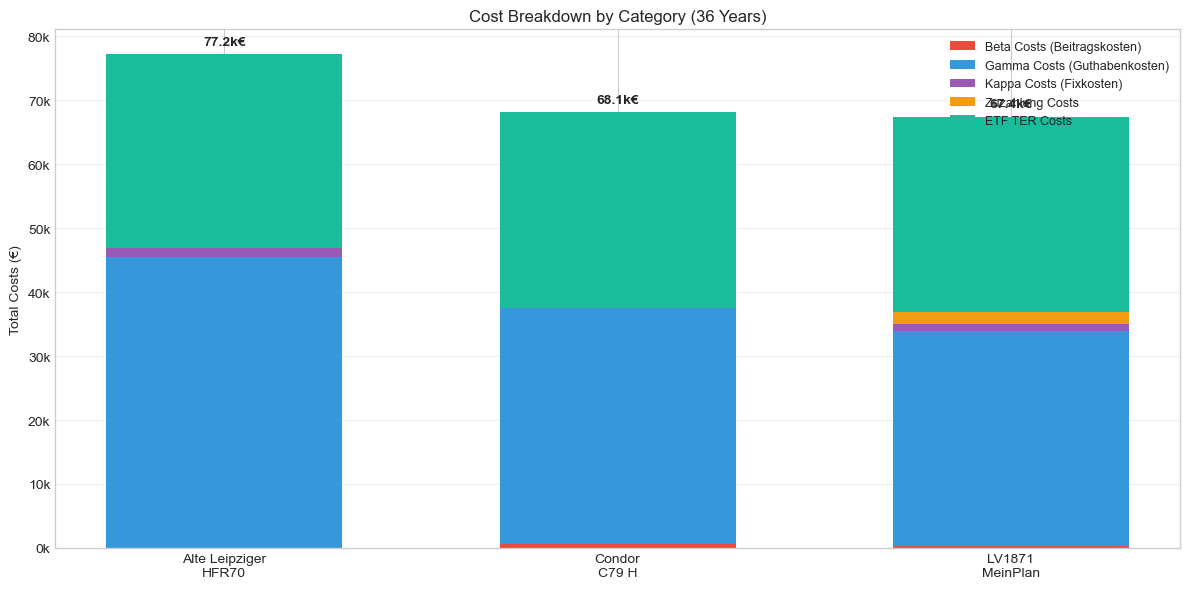

In [11]:
# Stacked bar chart for cost breakdown
fig, ax = plt.subplots(figsize=(12, 6))

cost_categories = ['Beta Costs (Beitragskosten)', 'Gamma Costs (Guthabenkosten)', 
                   'Kappa Costs (Fixkosten)', 'Zuzahlung Costs', 'ETF TER Costs']
category_colors = ['#e74c3c', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']

tariff_names_short = ['Alte Leipziger\nHFR70', 'Condor\nC79 H', 'LV1871\nMeinPlan']
x = np.arange(len(tariff_names_short))
width = 0.6

bottom = np.zeros(3)
for i, cat in enumerate(cost_categories):
    values = [breakdown_data[name][cat] for name in tariffs.keys()]
    ax.bar(x, values, width, label=cat, bottom=bottom, color=category_colors[i])
    bottom += values

ax.set_ylabel('Total Costs (€)')
ax.set_title('Cost Breakdown by Category (36 Years)')
ax.set_xticks(x)
ax.set_xticklabels(tariff_names_short)
ax.legend(loc='upper right', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
ax.grid(True, alpha=0.3, axis='y')

# Add total cost labels
for i, name in enumerate(tariffs.keys()):
    total = breakdown_data[name]['TOTAL COSTS']
    ax.text(i, total + 1000, f'{total/1000:.1f}k€', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Feature Comparison & Final Recommendation

In [12]:
# Feature comparison
features_data = []
for name, t in tariffs.items():
    features_data.append({
        'Tariff': name,
        'Zuzahlung → Guaranteed Rentenfaktor': '✅ Yes' if t['guaranteed_rentenfaktor_zuzahlung'] else '❌ No',
        'Treuhänder Verzicht': '✅ Yes' if t['treuhänder_verzicht'] else '❌ No',
        'Teilverrentung': '✅ Yes' if t['teilverrentung'] else '❌ No',
        'Fondsgebundener Rentenbezug': '✅ Yes' if t['fondsgebundener_rentenbezug'] else '❌ No',
    })

features_df = pd.DataFrame(features_data).set_index('Tariff')
print("Feature Comparison:")
print("=" * 70)
display(features_df)

# Final summary
print("\n" + "=" * 80)
print("FINAL SUMMARY - COST RANKING (Best to Worst)")
print("=" * 80)

# Sort by effective cost
ranking = sorted(
    [(name, results[name]['effective_cost_pct'], results[name]['final_value'], results[name]['total_costs']) 
     for name in tariffs.keys()],
    key=lambda x: x[1]
)

for i, (name, eff_cost, final_val, total_cost) in enumerate(ranking, 1):
    print(f"\n{i}. {name}")
    print(f"   Effective Cost: {eff_cost:.3f}% p.a.")
    print(f"   Final Portfolio: {final_val:,.0f}€")
    print(f"   Total Costs Paid: {total_cost:,.0f}€")
    print(f"   Cost Drag vs No-Cost: {no_cost_final - final_val:,.0f}€")

print("\n" + "=" * 80)
print(f"Benchmark (No Costs): {no_cost_final:,.0f}€")
print(f"Total Contributions: {total_contributions:,.0f}€")
print("=" * 80)

Feature Comparison:


,Zuzahlung → Guaranteed Rentenfaktor,Treuhänder Verzicht,Teilverrentung,Fondsgebundener Rentenbezug
Tariff,,,,
Alte Leipziger HFR70,❌ No,✅ Yes,❌ No,❌ No
Condor C79 H,✅ Yes,✅ Yes,✅ Yes,❌ No
LV1871 MeinPlan,✅ Yes,✅ Yes,❌ No,✅ Yes



FINAL SUMMARY - COST RANKING (Best to Worst)

1. Condor C79 H
   Effective Cost: 0.318% p.a.
   Final Portfolio: 1,174,022€
   Total Costs Paid: 68,150€
   Cost Drag vs No-Cost: 134,116€

2. LV1871 MeinPlan
   Effective Cost: 0.324% p.a.
   Final Portfolio: 1,171,693€
   Total Costs Paid: 67,435€
   Cost Drag vs No-Cost: 136,445€

3. Alte Leipziger HFR70
   Effective Cost: 0.365% p.a.
   Final Portfolio: 1,155,187€
   Total Costs Paid: 77,213€
   Cost Drag vs No-Cost: 152,951€

Benchmark (No Costs): 1,308,138€
Total Contributions: 372,960€


## Key Insights

### Your Strategy Analysis (30€/month + 10,000€/year Zuzahlung)

**Why your strategy is smart:**
- Condor charges 4.5% Beta on regular contributions but 0% on Zuzahlung → minimizing monthly contributions saves Beta costs
- LV1871 charges 2.2% Beta + 0.5% Zuzahlung cost → still benefits from lower Zuzahlung cost
- Alte Leipziger has 0% on both, so the split doesn't matter for costs

**Important Considerations:**
1. **Alte Leipziger** has the lowest costs but NO guaranteed Rentenfaktor on Zuzahlung
2. **Condor** offers guaranteed Rentenfaktor on Zuzahlung + Teilverrentung option
3. **LV1871** offers guaranteed Rentenfaktor + fondsgebundener Rentenbezug (investment during retirement)

**Cost differences compound significantly over 36 years!**